In [19]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [20]:
preflop_path = Path.cwd().parent / 'training' / 'preflops'  
rng_seed = 42

def get_potbet_path(iter):
    return preflop_path / ("potbet_prob_" + str(iter) + ".csv")

def get_limp_path(iter):
    return preflop_path / ("limp_prob_" + str(iter) + ".csv") 

In [21]:
import numpy as np
import matplotlib.pyplot as plt

RANKS = "AKQJT98765432"


def hand_name(i: int, j: int) -> str:
    """Standard grid convention: diag=pair, upper-right=suited, lower-left=offsuit."""
    hi, lo = RANKS[min(i, j)], RANKS[max(i, j)]
    if i == j:
        return hi + hi
    return hi + lo + ("s" if i < j else "o")


def plot_preflop_grid(df, prob_col="prob", ax=None, title=None):
    """13x13 preflop grid from a df with columns [hand, prob_col], colored red->green."""
    probs = dict(zip(df["hand"], df[prob_col]))
    grid = np.array([[probs.get(hand_name(i, j), np.nan) for j in range(13)]
                     for i in range(13)])

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 9))

    ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1)

    for i in range(13):
        for j in range(13):
            v = grid[i, j]
            label = hand_name(i, j) if np.isnan(v) else f"{hand_name(i, j)}\n{v:.0%}"
            ax.text(j, i, label, ha="center", va="center", fontsize=7)

    # white gridlines between cells, no outer frame or tick marks
    ax.set_xticks(np.arange(-0.5, 13), minor=True)
    ax.set_yticks(np.arange(-0.5, 13), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(range(13), RANKS)
    ax.set_yticks(range(13), RANKS)
    ax.set_title(title or prob_col, fontsize=12, pad=10)
    return ax

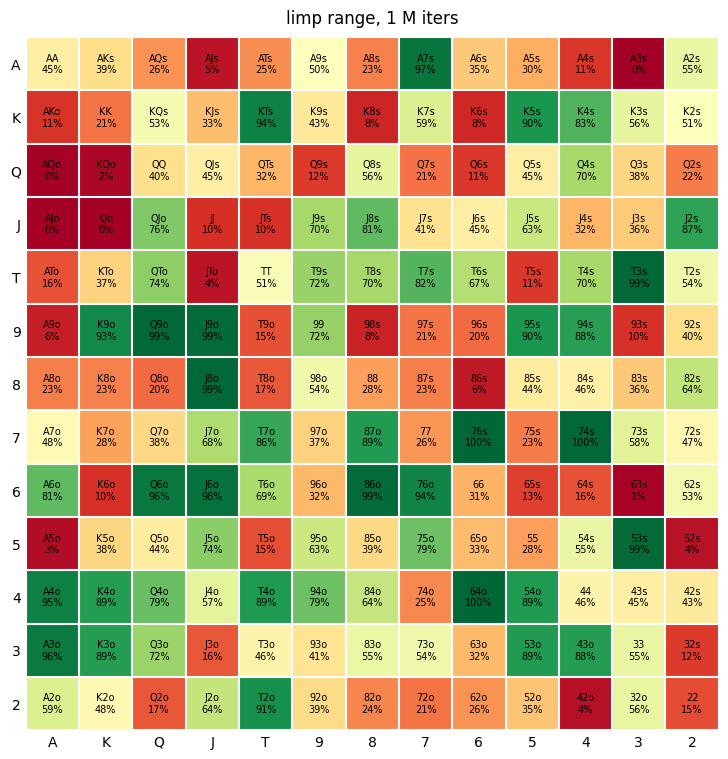

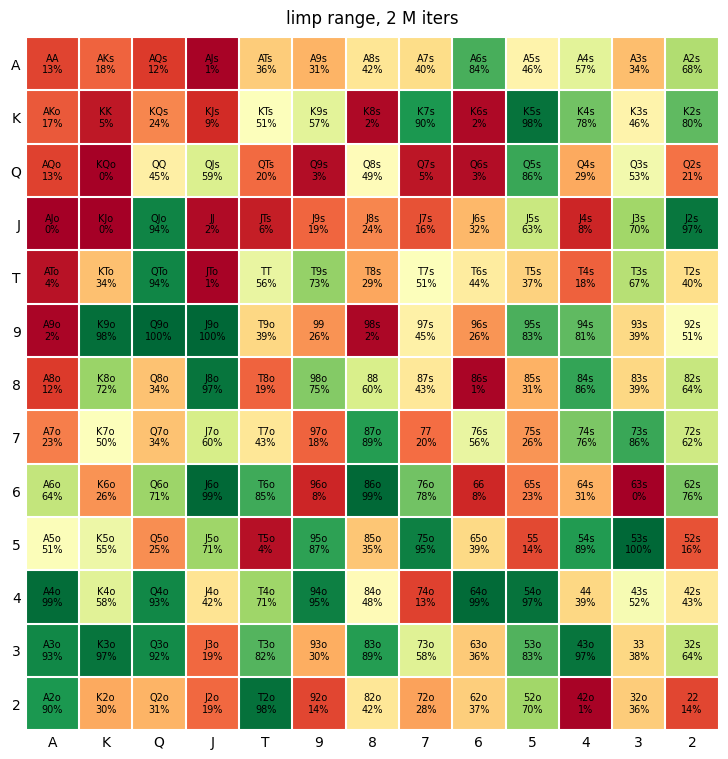

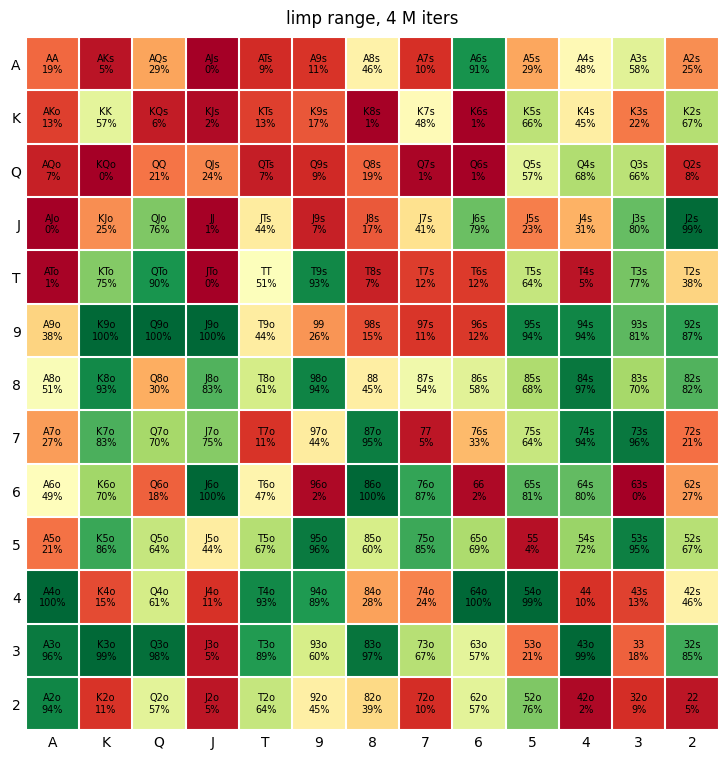

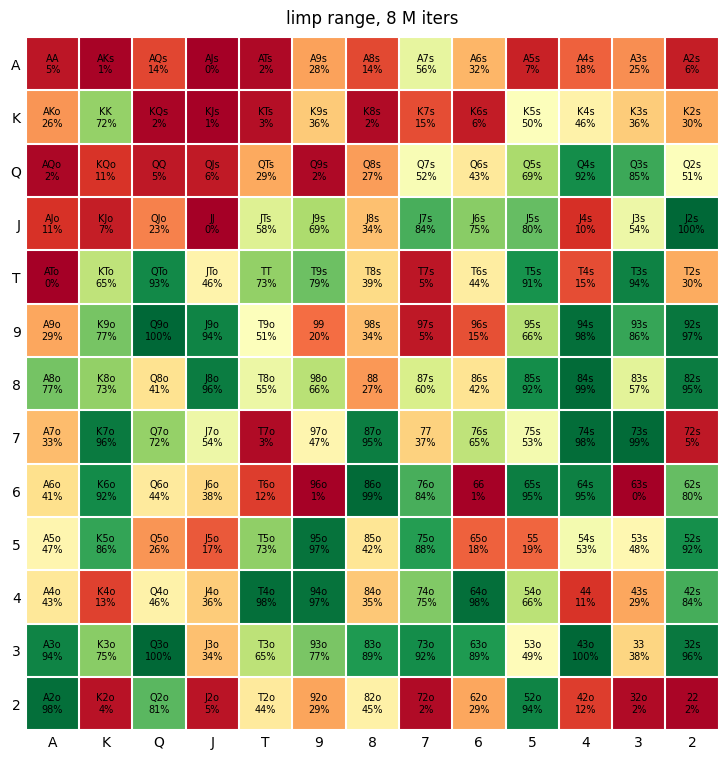

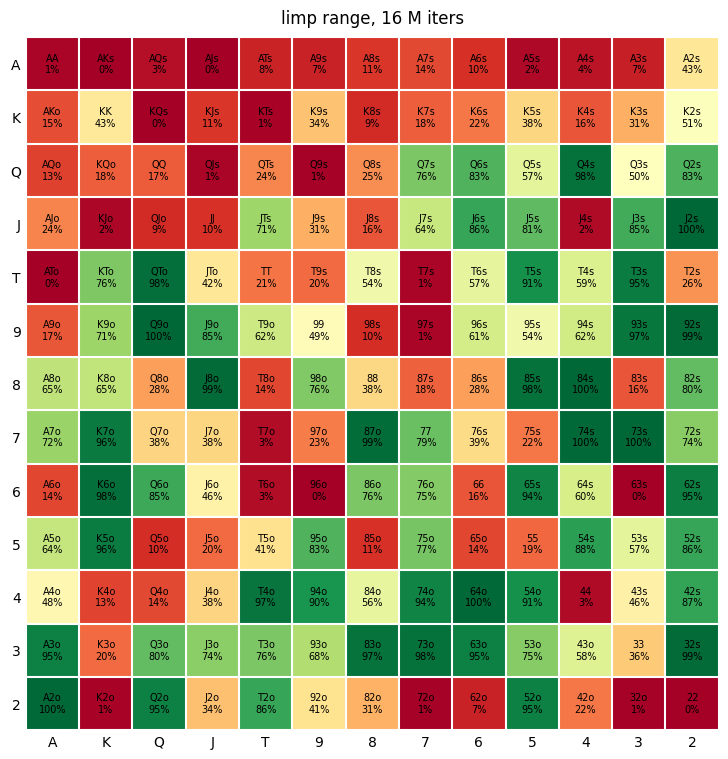

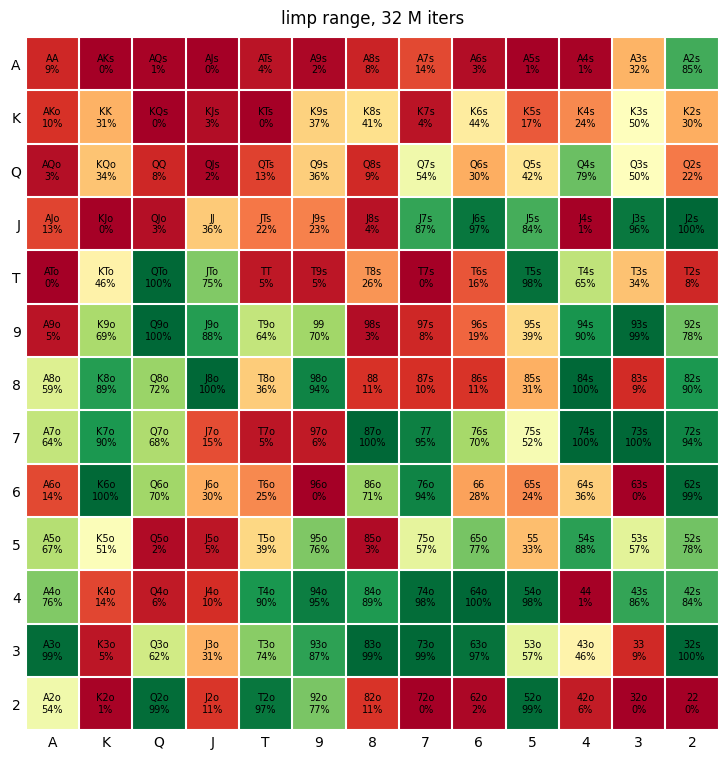

In [25]:
ckpt_iters = [1,2,4,8,16, 32] #32,64,128, 256, 512]

for val in ckpt_iters:
    iter =  1_000_000*val

    limp_df = pd.read_csv(get_limp_path(iter))
    plot_preflop_grid(limp_df, title=f"limp range, {val} M iters")





In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

RANKS = "AKQJT98765432"
COLORS = {"raise": "#e07b6a", "limp": "#8bbf8b", "fold": "#7ea3c4"}


def hand_name(i: int, j: int) -> str:
    hi, lo = RANKS[min(i, j)], RANKS[max(i, j)]
    return hi + hi if i == j else hi + lo + ("s" if i < j else "o")


def n_combos(i: int, j: int) -> int:
    return 6 if i == j else (4 if i < j else 12)


def plot_preflop_actions(df_raise, df_limp, prob_col="prob", ax=None, title=None,
                         labels=("Raise", "Limp", "Fold")):
    """13x13 grid, each cell filled left->right by raise/limp/fold frequency."""
    p_raise = dict(zip(df_raise["hand"], df_raise[prob_col]))
    p_limp = dict(zip(df_limp["hand"], df_limp[prob_col]))

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))

    weighted = np.zeros(3)
    total = 0.0

    for i in range(13):
        for j in range(13):
            h = hand_name(i, j)
            r = float(p_raise.get(h, 0.0))
            l = float(p_limp.get(h, 0.0))
            f = max(0.0, 1.0 - r - l)
            c = n_combos(i, j)
            weighted += np.array([r, l, f]) * c
            total += c

            x = j - 0.5
            for w, key in zip((r, l, f), ("raise", "limp", "fold")):
                if w > 0:
                    ax.add_patch(Rectangle((x, i - 0.5), w, 1,
                                           facecolor=COLORS[key], edgecolor="none"))
                    x += w
            ax.text(j, i, h, ha="center", va="center", fontsize=7.5,
                    color="black", zorder=3)

    ax.set_xlim(-0.5, 12.5)
    ax.set_ylim(12.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(-0.5, 13), minor=True)
    ax.set_yticks(np.arange(-0.5, 13), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(range(13), RANKS)
    ax.set_yticks(range(13), RANKS)
    ax.set_title(title or "Preflop strategy", fontsize=12, pad=10)

    handles = [Rectangle((0, 0), 1, 1, facecolor=COLORS[k]) for k in ("raise", "limp", "fold")]
    texts = [f"{name}  {w / total:.1%}  ({w:.1f} combos)"
             for name, w in zip(labels, weighted)]
    ax.legend(handles, texts, loc="upper center", bbox_to_anchor=(0.5, -0.04),
              ncol=3, frameon=False, fontsize=10)
    return ax

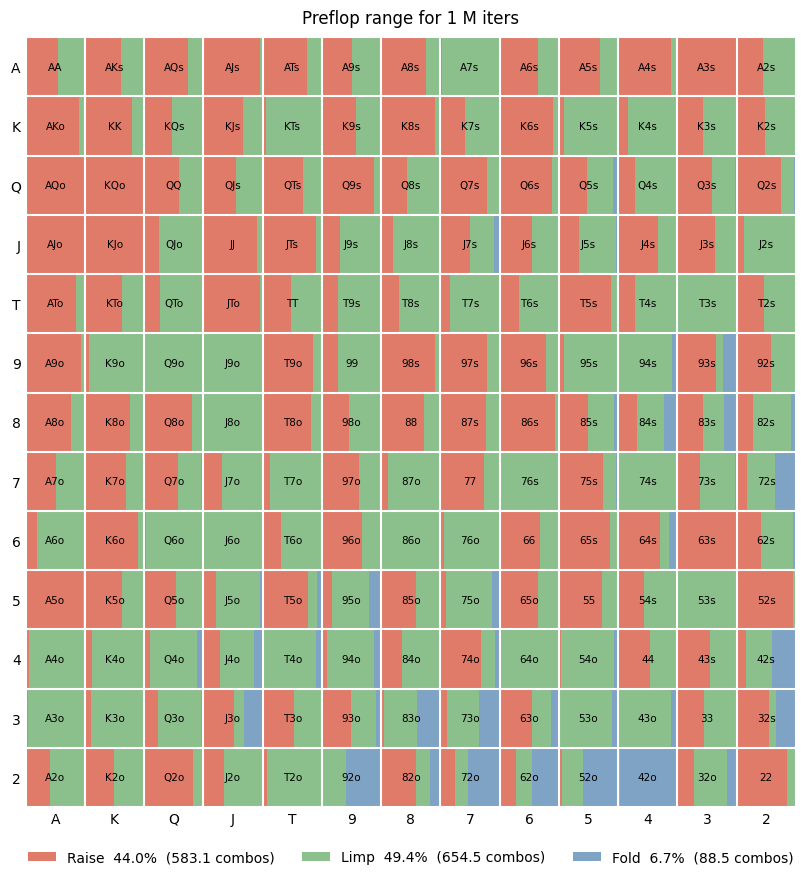

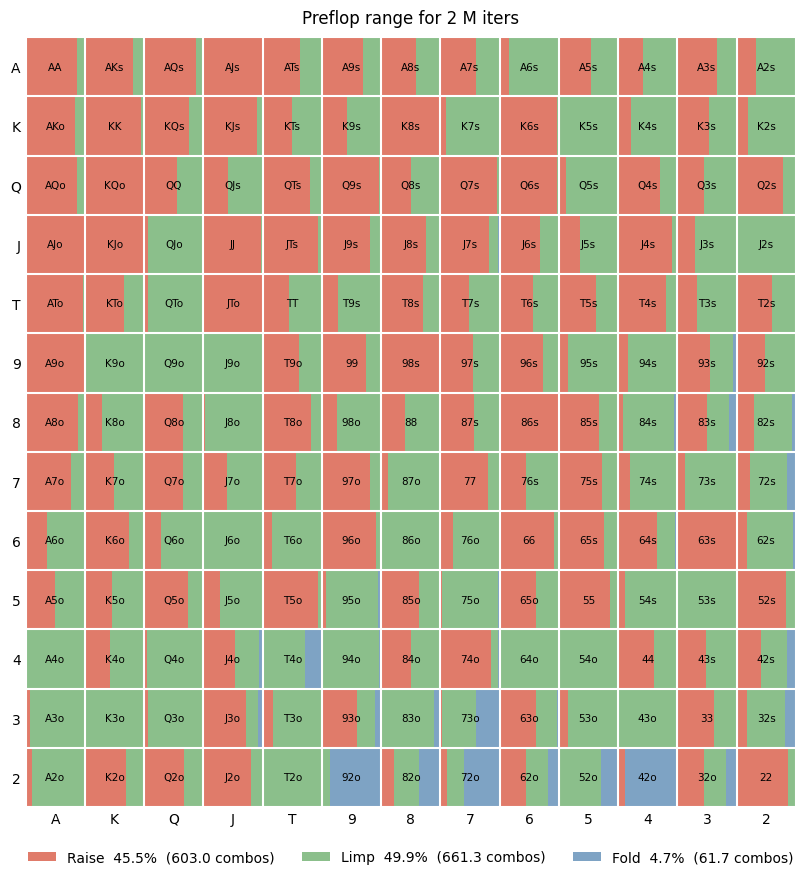

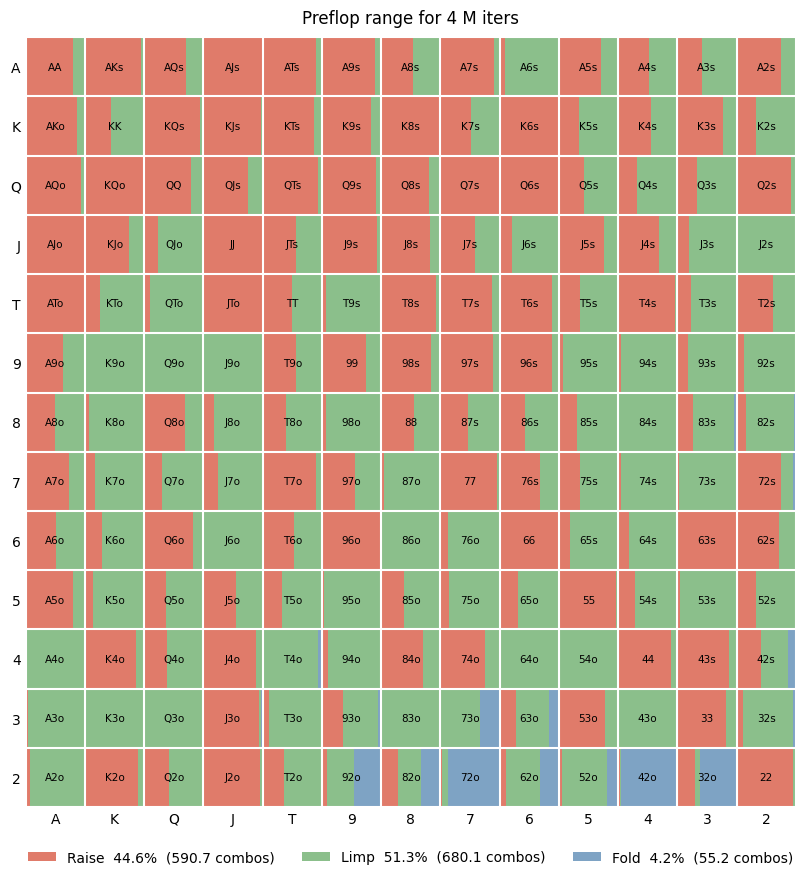

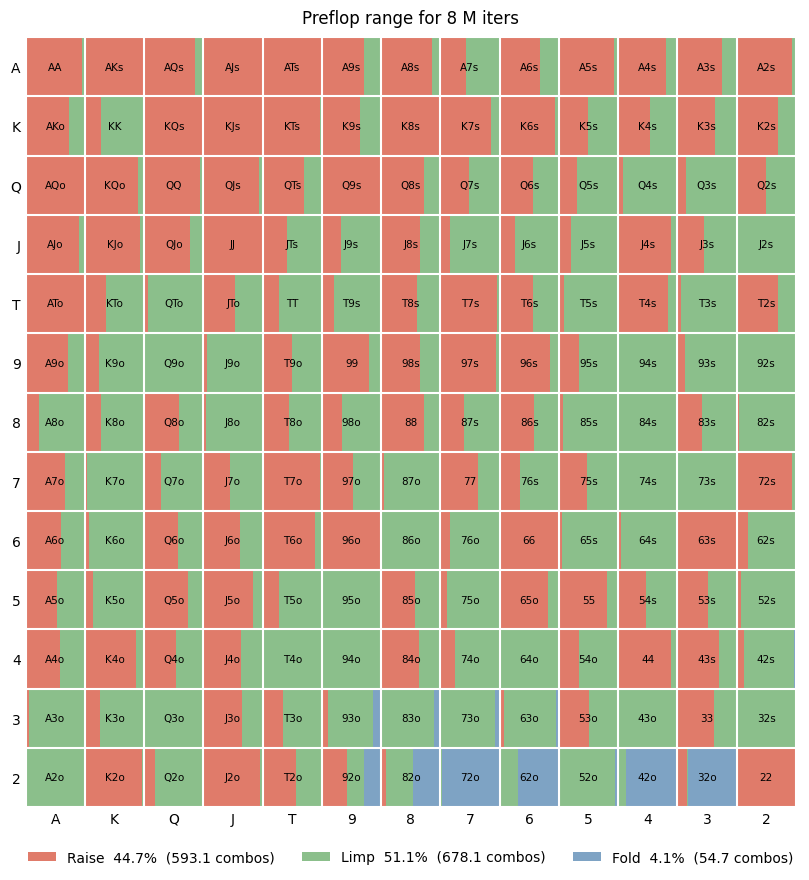

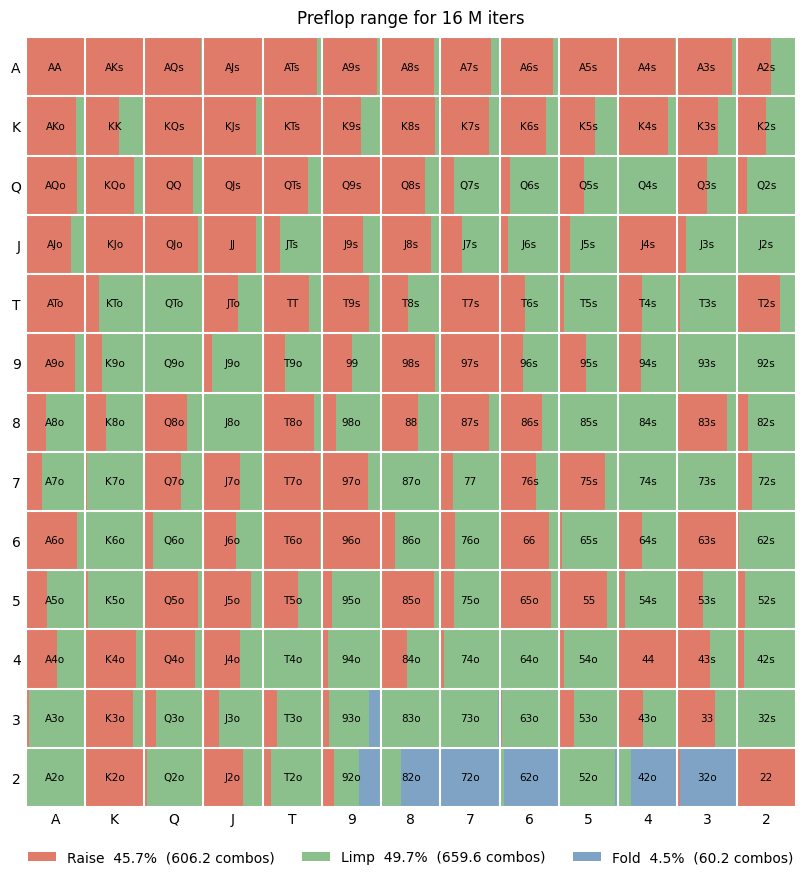

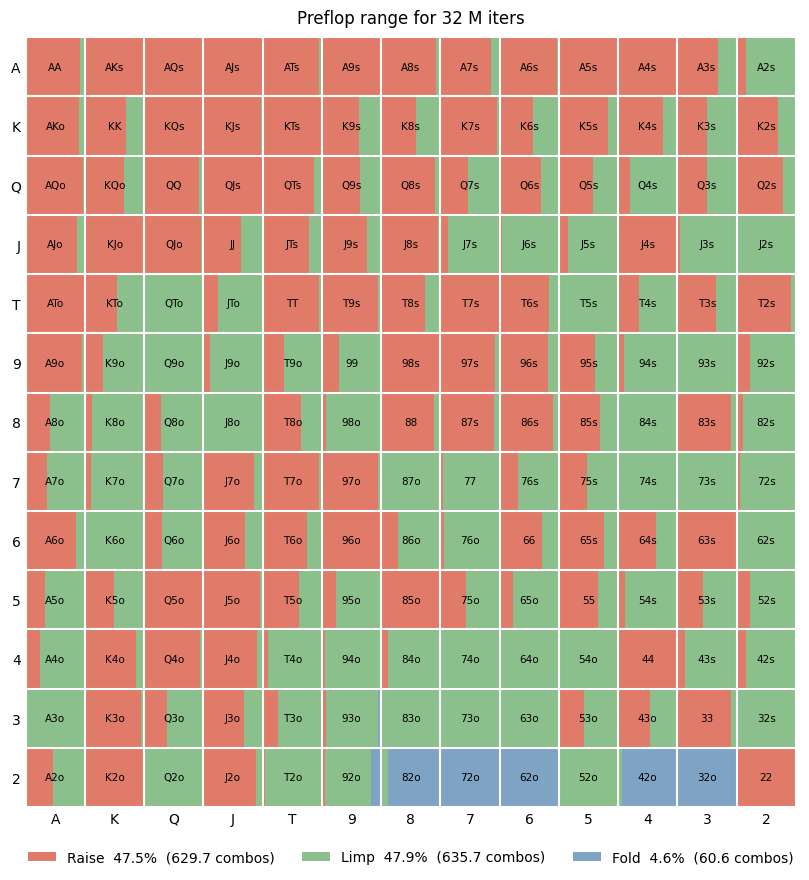

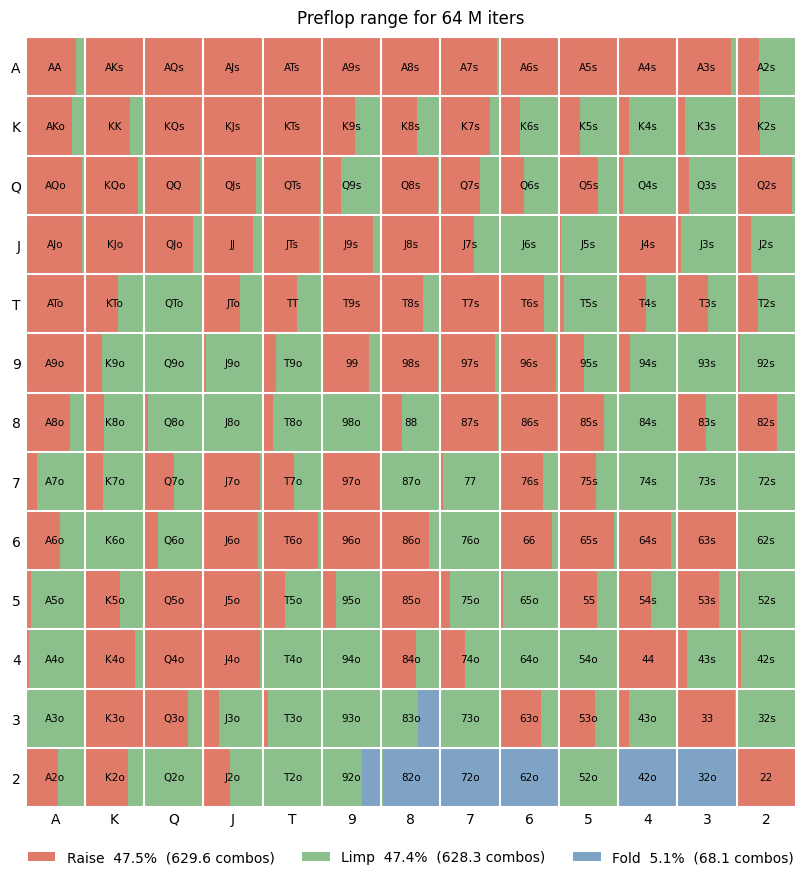

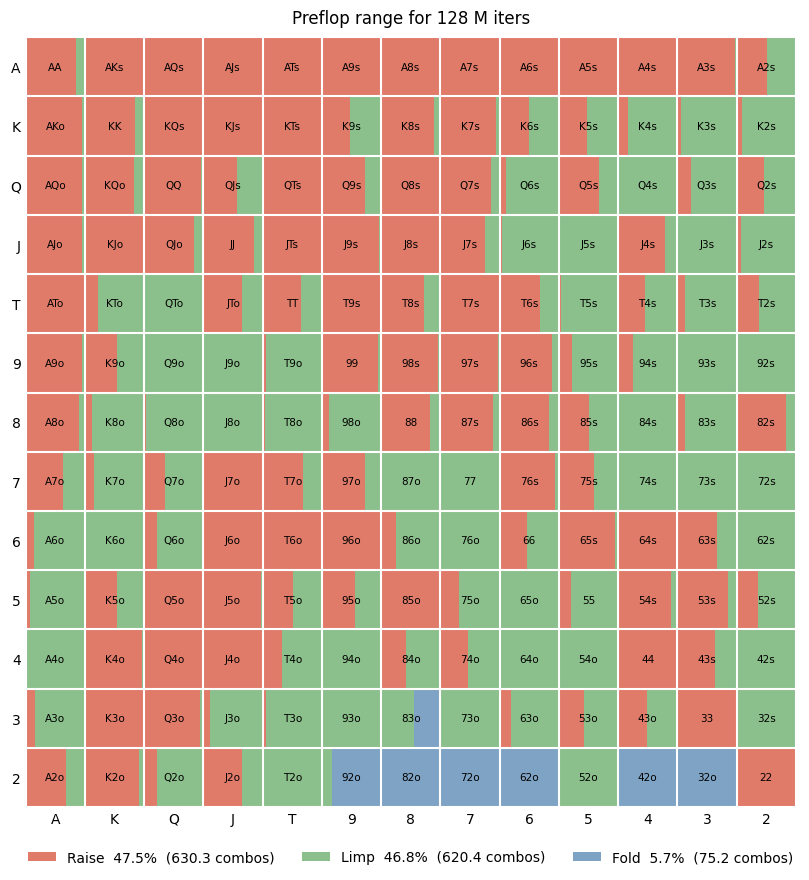

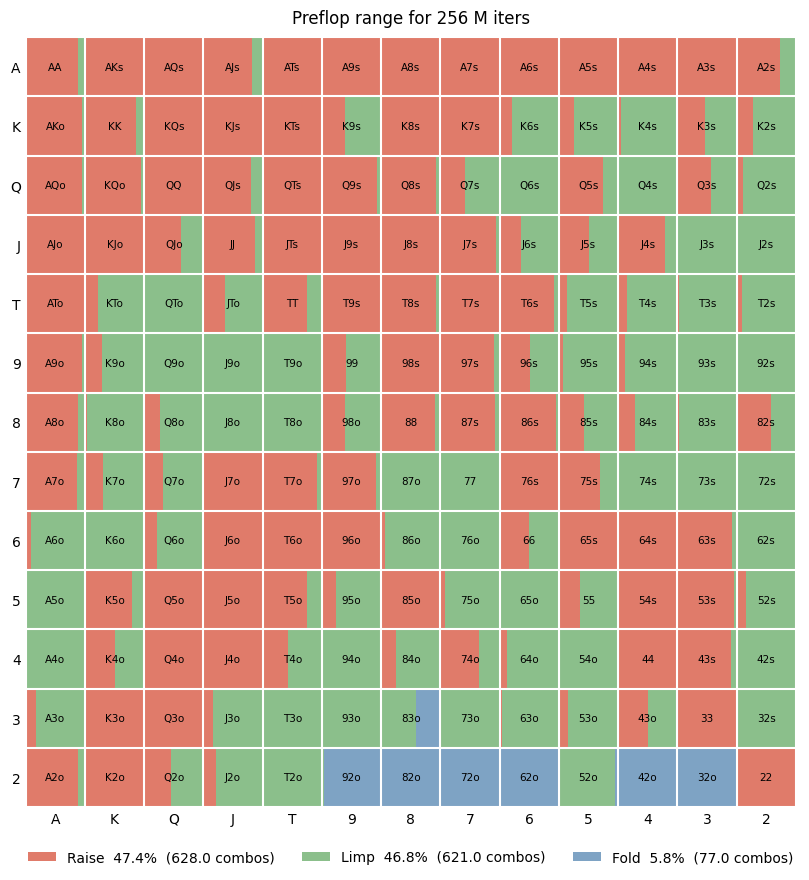

In [30]:
ckpt_iters = [1,2,4,8,16, 32, 64, 128, 256] #32,64,128, 256, 512]

for val in ckpt_iters:
    iter =  1_000_000*val

    limp_df = pd.read_csv(get_limp_path(iter))
    potbet_df = pd.read_csv(get_potbet_path(iter))

    title = "Preflop range for " + str(val) + " M iters"

    plot_preflop_actions(potbet_df, limp_df, prob_col="prob", ax = None, title = title)
   
